# 01 — Exploratory Data Analysis (EDA)
**Anaemia Prediction using ML & Explainable AI**

> ⚠️ Educational decision-support prototype — **not** a diagnostic tool.

Goals of this notebook:
1. Understand the data (size, types, missing values, balance).
2. Visualise feature distributions and correlations.
3. **Leakage check** — is the `Result` label just a haemoglobin rule?
All figures are saved to `reports/figures/` for the report and PPT.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))  # make 'src' importable from notebooks/
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import config
from src.data_loader import load_raw, load_clean
sns.set_theme(style='whitegrid')
FIG = config.FIGURES_DIR
FIG.mkdir(parents=True, exist_ok=True)
print('Setup OK. Figures ->', FIG)

Setup OK. Figures -> /home/Clyton/Projects/AnemiaPrediction/reports/figures


## 1. Load the data
`load_clean()` removes 887 exact-duplicate rows (see why in `src/data_loader.py`).

In [2]:
raw = load_raw()
df  = load_clean()
print('raw shape   :', raw.shape)
print('clean shape :', df.shape, '(after dropping', len(raw)-len(df), 'duplicates)')
df.head()

raw shape   : (1421, 6)
clean shape : (534, 6) (after dropping 887 duplicates)


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


## 2. Structure, missing values, summary stats

In [3]:
print('DTYPES:\n', df.dtypes, '\n')
print('MISSING VALUES:\n', df.isna().sum(), '\n')
df.describe().round(2)

DTYPES:
 Gender          int64
Hemoglobin    float64
MCH           float64
MCHC          float64
MCV           float64
Result          int64
dtype: object 

MISSING VALUES:
 Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64 



,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,534.00,534.00,534.00,534.00,534.00,534.00
mean,0.52,13.29,22.91,30.25,85.65,0.46
std,0.50,2.07,3.95,1.41,9.60,0.50
min,0.00,6.60,16.00,27.80,69.40,0.00
25%,0.00,11.60,19.50,29.00,77.32,0.00
50%,1.00,13.10,22.75,30.40,85.45,0.00
75%,1.00,14.98,26.10,31.48,94.15,1.00
max,1.00,16.90,30.00,32.50,101.60,1.00


## 3. Class balance
How many anaemic vs non-anaemic patients? Balanced classes make accuracy meaningful.

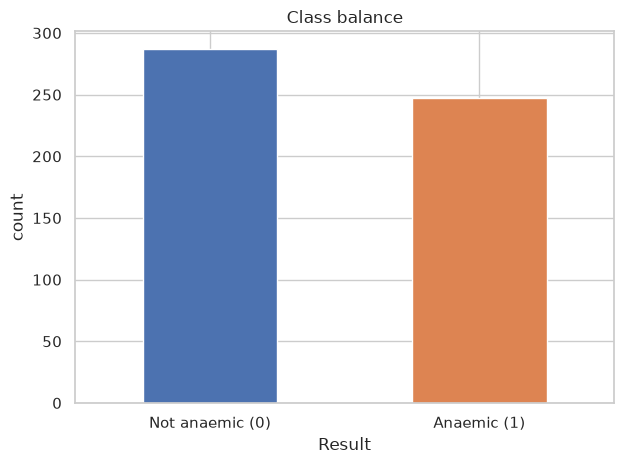

Result
0    53.7 %
1    46.3 %
Name: proportion, dtype: str


In [4]:
counts = df[config.TARGET].value_counts().sort_index()
ax = counts.plot(kind='bar', color=['#4c72b0','#dd8452'])
ax.set_xticklabels(['Not anaemic (0)','Anaemic (1)'], rotation=0)
ax.set_title('Class balance'); ax.set_ylabel('count')
plt.tight_layout(); plt.savefig(FIG/'fig_target_balance.png', dpi=120); plt.show()
print((df[config.TARGET].value_counts(normalize=True)*100).round(1).astype(str)+' %')

## 4. Feature distributions
The shape of each feature: are values reasonable, skewed, or bimodal?

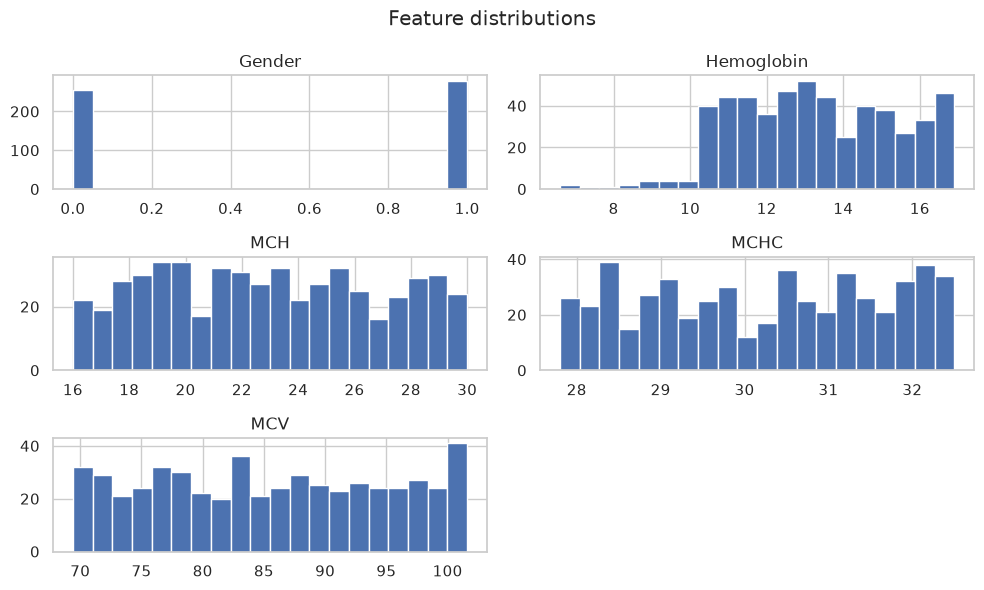

In [5]:
df[config.FEATURES].hist(figsize=(10,6), bins=20, color='#4c72b0', edgecolor='white')
plt.suptitle('Feature distributions')
plt.tight_layout(); plt.savefig(FIG/'fig_distributions.png', dpi=120); plt.show()

## 5. Feature distributions split by anaemia status
If a feature separates the two classes, it carries predictive signal. Watch Haemoglobin.

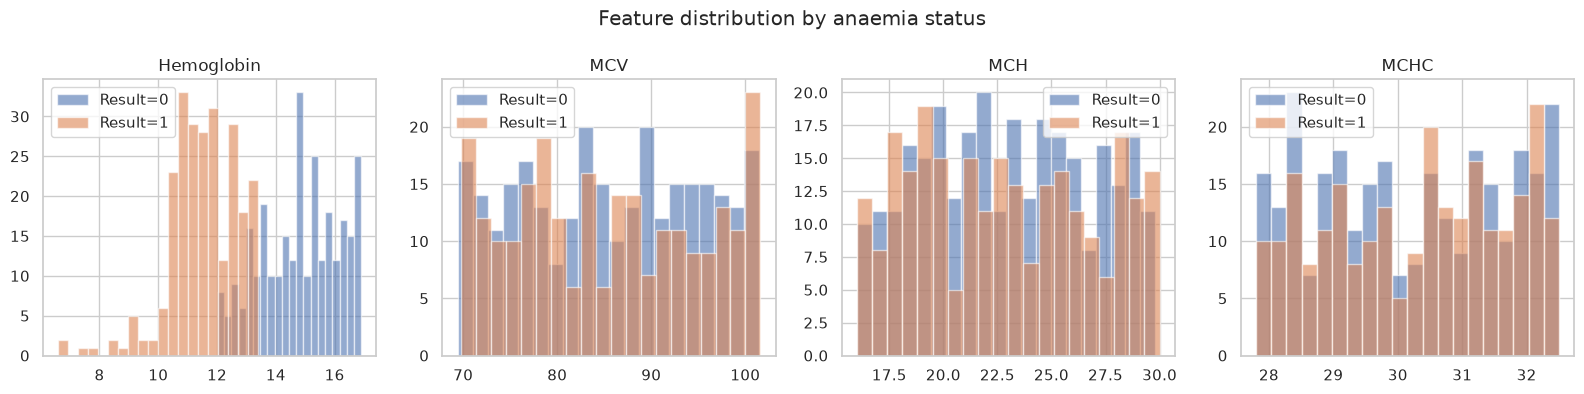

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, ['Hemoglobin','MCV','MCH','MCHC']):
    for r, g in df.groupby(config.TARGET):
        ax.hist(g[col], bins=20, alpha=0.6, label=f'Result={r}')
    ax.set_title(col); ax.legend()
plt.suptitle('Feature distribution by anaemia status')
plt.tight_layout(); plt.savefig(FIG/'fig_dist_by_class.png', dpi=120); plt.show()

## 6. Correlation matrix
Which features move together, and which correlate with `Result`?

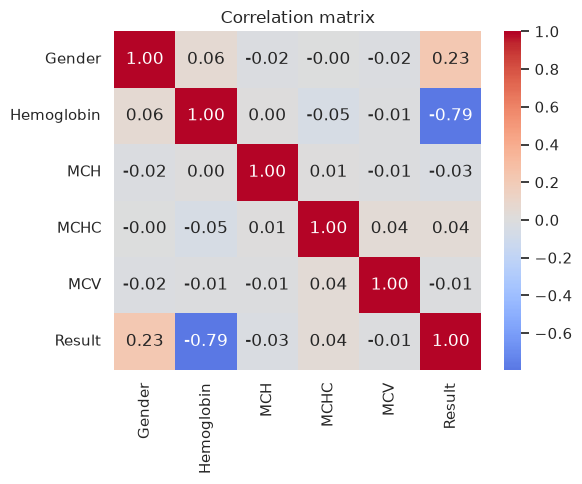

In [7]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout(); plt.savefig(FIG/'fig_correlation.png', dpi=120); plt.show()

## 7. Leakage check (the headline finding)
Anaemia's clinical definition is a **gender-specific haemoglobin cutoff** (WHO: female < 12 g/dL, male < 13 g/dL). If `Result` was generated by that rule, a model trained on Hb will hit ~100% accuracy by reverse-engineering the rule — **data leakage**, not medical skill. Let's test it.

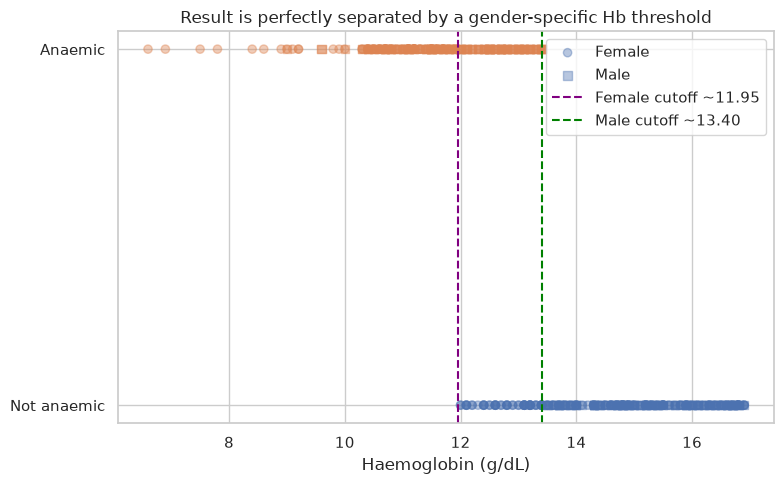

In [8]:
plt.figure(figsize=(8,5))
for g in [0,1]:
    sub = df[df['Gender']==g]
    plt.scatter(sub['Hemoglobin'], sub[config.TARGET],
                c=sub[config.TARGET].map({0:'#4c72b0',1:'#dd8452'}),
                marker='o' if g==0 else 's', alpha=0.4,
                label=config.GENDER_MAP[g])
plt.axvline(11.95, color='purple', ls='--', label='Female cutoff ~11.95')
plt.axvline(13.40, color='green',  ls='--', label='Male cutoff ~13.40')
plt.yticks([0,1], ['Not anaemic','Anaemic'])
plt.xlabel('Haemoglobin (g/dL)')
plt.title('Result is perfectly separated by a gender-specific Hb threshold')
plt.legend(); plt.tight_layout(); plt.savefig(FIG/'fig_leakage_hb_scatter.png', dpi=120); plt.show()

In [9]:
# Apply the WHO-style rule directly and measure how well it reproduces the label.
pred = np.zeros(len(df), dtype=int)
pred[(df['Gender']==0) & (df['Hemoglobin'] < 11.95)] = 1   # female
pred[(df['Gender']==1) & (df['Hemoglobin'] < 13.40)] = 1   # male
acc = (pred == df[config.TARGET].values).mean()
print(f'Gender-specific Hb rule reproduces Result with {acc*100:.1f}% accuracy')
print('=> The label IS essentially this rule. This is label leakage.')

Gender-specific Hb rule reproduces Result with 98.9% accuracy
=> The label IS essentially this rule. This is label leakage.


## 8. EDA summary / findings
- **534 unique patients** after removing 887 duplicates; no missing values.
- Classes are reasonably balanced (~56% not anaemic / 44% anaemic).
- `Gender` is pre-encoded (0=Female, 1=Male).
- **Leakage confirmed:** `Result` is a gender-specific Hb threshold (≈100% reproducible). We report this honestly; the project's contribution is the **comparison + explainability pipeline**, and we run an **Hb-excluded experiment** to test whether MCV/MCH/MCHC carry real signal.
- Next: **Phase 3 preprocessing** — stratified split, scaling, save the scaler.